# Tree models (Random Forest, Gradient Boosting, XGBoost)

Adds the non-linear models to the comparison (Random Forest and Gradient Boosting from Phase 5; XGBoost from Phase 6). Unlike Ridge, trees are scale-invariant, so they use the **full** feature set including the raw ordinal time columns (`hour`, `month`, `dayofweek`, `year`) that the linear pipeline had to drop. All are trained on `log1p(count)` with the clipped inverse, so predictions stay non-negative. Hyperparameters live in `config/models.yaml`; metrics come from `reports/metrics.json`. This notebook is diagnostic, not part of the runtime pipeline.

## Setup

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from bike_sharing.config import load_config

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "config" / "config.yaml").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate config/config.yaml above cwd.")
    PROJECT_ROOT = PROJECT_ROOT.parent

CFG = load_config(PROJECT_ROOT / "config" / "config.yaml")
REPORTS_DIR = Path(CFG["paths"]["reports_dir"])
FIG_DIR = REPORTS_DIR / "figures"
MODELS_DIR = Path(CFG["paths"]["models_dir"])
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid")
metrics = json.loads((REPORTS_DIR / "metrics.json").read_text())
print("models in metrics.json:", sorted(metrics))


models in metrics.json: ['gradient_boosting', 'hourly_mean_baseline', 'mean_baseline', 'random_forest', 'ridge', 'xgboost']


## 1. Model comparison

All four metrics on both validation views (chronological CV and the day-of-month holdout). Read them together; RMSLE is shown first because the target is right-skewed.

In [2]:
# All five models on both validation views, all four metrics.
rows = []
for name, summary in metrics.items():
    cv = summary["cv"]["mean"]
    hold = summary["day_of_month_holdout"]["metrics"]
    rows.append({
        "model": name,
        "cv_rmsle": cv["rmsle"],
        "holdout_rmsle": hold["rmsle"],
        "holdout_rmse": hold["rmse"],
        "holdout_mae": hold["mae"],
        "holdout_r2": hold["r2"],
    })
table = pd.DataFrame(rows).set_index("model").sort_values("holdout_rmsle")
table.round(3)


,cv_rmsle,holdout_rmsle,holdout_rmse,holdout_mae,holdout_r2
model,,,,,
xgboost,0.447,0.309,46.459,27.615,0.936
random_forest,0.514,0.330,51.865,30.366,0.920
gradient_boosting,0.471,0.334,59.005,36.508,0.896
hourly_mean_baseline,0.739,0.755,125.884,86.065,0.527
ridge,0.987,0.905,162.224,106.179,0.214
mean_baseline,1.402,1.531,183.077,142.644,-0.001


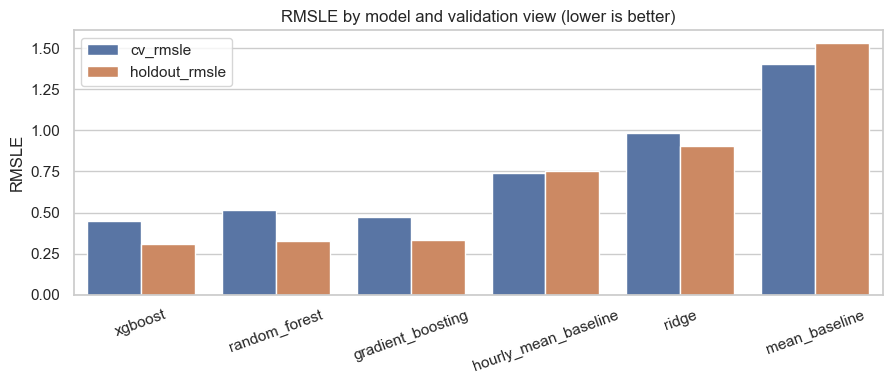

In [3]:
order = table.index.tolist()
fig, ax = plt.subplots(figsize=(9, 4))
plot_df = (
    table[["cv_rmsle", "holdout_rmsle"]]
    .reset_index()
    .melt(id_vars="model", var_name="view", value_name="rmsle")
)
sns.barplot(data=plot_df, x="model", y="rmsle", hue="view", order=order, ax=ax)
ax.set_title("RMSLE by model and validation view (lower is better)")
ax.set_xlabel("")
ax.set_ylabel("RMSLE")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="")
fig.tight_layout()
fig.savefig(FIG_DIR / "12_model_comparison_rmsle.png", dpi=120, bbox_inches="tight")
plt.show()


## 2. Feature importances

Which inputs the trees rely on, to connect model behavior back to the project's temporal and environmental questions rather than just reporting a score. These are impurity-based (mean impurity decrease, normalized to sum to 1) — a quick diagnostic split importance, not a causal measure: it is biased toward continuous and high-cardinality features and can split correlated inputs (e.g. `temp`/`atemp`, `hour` vs its cyclic encodings) arbitrarily between them. For a stronger claim in the Phase 7 report, permutation importance on the day-of-month holdout would be the next step; the broad temporal-vs-environmental tiering below is robust enough for this stage.

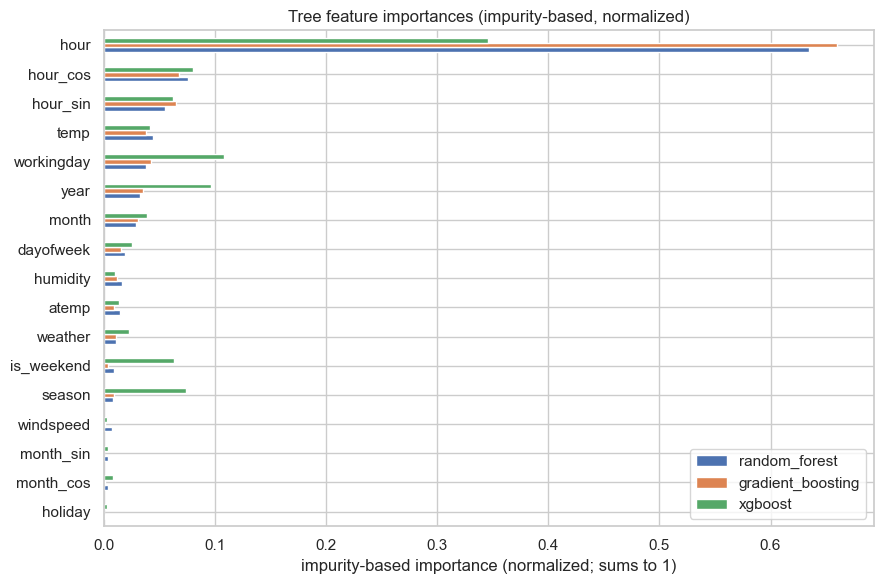

,random_forest,gradient_boosting,xgboost
hour,0.635,0.660,0.345
hour_cos,0.076,0.068,0.081
hour_sin,0.055,0.065,0.062
temp,0.044,0.038,0.041
workingday,0.038,0.042,0.108
year,0.033,0.035,0.096
month,0.029,0.030,0.038
dayofweek,0.019,0.016,0.025
humidity,0.016,0.012,0.010
atemp,0.014,0.009,0.014


In [4]:
# Feature importances from the persisted tree models. The estimator is a
# TransformedTargetRegressor; the fitted tree is at `.regressor_`.
train_cols = pd.read_parquet(
    Path(CFG["paths"]["processed_dir"]) / "train.parquet"
).drop(columns=[CFG["target"], CFG["datetime_col"]]).columns.tolist()

imp = {}
for name in ("random_forest", "gradient_boosting", "xgboost"):
    path = MODELS_DIR / f"{name}.joblib"
    if not path.exists():
        continue
    model = joblib.load(path)
    imp[name] = pd.Series(model.regressor_.feature_importances_, index=train_cols)

imp_df = pd.DataFrame(imp).sort_values("random_forest", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
imp_df.plot(kind="barh", ax=ax)
ax.set_title("Tree feature importances (impurity-based, normalized)")
ax.set_xlabel("impurity-based importance (normalized; sums to 1)")
ax.set_ylabel("")
ax.legend(title="")
fig.tight_layout()
fig.savefig(FIG_DIR / "13_tree_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
imp_df.sort_values("random_forest", ascending=False).round(3)


## Findings (interpretation for the report)

- All three tree models decisively beat the baselines and Ridge on every metric and both validation views. Capturing the `hour × workingday` interaction non-linearly is exactly what the linear model could not do with first-harmonic cyclic features. XGBoost is the strongest (day-of-month holdout RMSLE 0.31, R² 0.94), narrowly ahead of Random Forest and Gradient Boosting.
- Feature importance is dominated by the **temporal** signal — `hour` (and its cyclic encodings) plus `workingday`/`year` — confirming the EDA story that time-of-day drives demand. This directly answers the proposal's temporal-pattern question.
- **Environmental** inputs (`temp`/`atemp`, `humidity`, `weather`, `season`) form the next tier: real but secondary. That is the environmental-impact narrative — weather modulates demand around the dominant daily rhythm rather than setting it.
- Among the trees the gaps are small. XGBoost edges ahead on both views (holdout RMSLE 0.31, CV 0.45); Random Forest and Gradient Boosting are a near-tie behind it and even swap order between views (RF leads the holdout 0.330 vs 0.334, GB leads the CV 0.471 vs 0.514). Treat the three as close rather than reading a decisive winner from one metric. The holdout R² (~0.90+) shows all three generalize to the later days of each month, the harder split.
- The persisted XGBoost model produces the test-set `datetime,count` prediction artifact via `scripts/generate_submission.py`. Phase 7 consolidates these results and interpretations into the written report. Any hyperparameter tuning beyond the current `config/models.yaml` defaults would be a `docs/experiments/` plan, per AGENTS.md §7.